<a href="https://colab.research.google.com/github/crrbnsn/deepfake-detection-cyb486/blob/main/Crystal_Mouth_Region_Deepfake_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deepfake Detection — Mouth Region Model
### CYB-486/586 | University of Michigan | Dr. Kutub
### Crystal Robinson | rrcrbnsn@umich.edu

## Project Overview
This notebook trains EfficientNet-B4 on mouth region crops from the
FaceForensics++ dataset to detect deepfake manipulation artifacts
in the perioral region. Grad-CAM heatmaps are generated to provide
forensic explainability for each prediction.



# Downloads/Installs/Imports

Mount Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Downloads

In [ ]:
full_code = '''#!/usr/bin/env python
import argparse
import os
import urllib
import urllib.request
import tempfile
import time
import sys
import json
import random
from tqdm import tqdm
from os.path import join

FILELIST_URL = "misc/filelist.json"
DEEPFEAKES_DETECTION_URL = "misc/deepfake_detection_filenames.json"
DEEPFAKES_MODEL_NAMES = ["decoder_A.h5", "decoder_B.h5", "encoder.h5"]

DATASETS = {
    "original_youtube_videos": "misc/downloaded_youtube_videos.zip",
    "original_youtube_videos_info": "misc/downloaded_youtube_videos_info.zip",
    "original": "original_sequences/youtube",
    "DeepFakeDetection_original": "original_sequences/actors",
    "Deepfakes": "manipulated_sequences/Deepfakes",
    "DeepFakeDetection": "manipulated_sequences/DeepFakeDetection",
    "Face2Face": "manipulated_sequences/Face2Face",
    "FaceShifter": "manipulated_sequences/FaceShifter",
    "FaceSwap": "manipulated_sequences/FaceSwap",
    "NeuralTextures": "manipulated_sequences/NeuralTextures"
}
ALL_DATASETS = ["original", "DeepFakeDetection_original", "Deepfakes",
                "DeepFakeDetection", "Face2Face", "FaceShifter", "FaceSwap",
                "NeuralTextures"]
COMPRESSION = ["raw", "c23", "c40"]
TYPE = ["videos", "masks", "models"]
SERVERS = ["EU", "EU2", "CA"]

def parse_args():
    parser = argparse.ArgumentParser(description="Downloads FaceForensics v2 public data release.")
    parser.add_argument("output_path", type=str, help="Output directory.")
    parser.add_argument("-d", "--dataset", type=str, default="all", choices=list(DATASETS.keys()) + ["all"])
    parser.add_argument("-c", "--compression", type=str, default="raw", choices=COMPRESSION)
    parser.add_argument("-t", "--type", type=str, default="videos", choices=TYPE)
    parser.add_argument("-n", "--num_videos", type=int, default=None)
    parser.add_argument("--server", type=str, default="EU", choices=SERVERS)
    args = parser.parse_args()
    if args.server == "EU":
        server_url = "http://canis.vc.in.tum.de:8100/"
    elif args.server == "EU2":
        server_url = "http://kaldir.vc.in.tum.de/faceforensics/"
    elif args.server == "CA":
        server_url = "http://falas.cmpt.sfu.ca:8100/"
    args.tos_url = server_url + "webpage/FaceForensics_TOS.pdf"
    args.base_url = server_url + "v3/"
    args.deepfakes_model_url = server_url + "v3/manipulated_sequences/Deepfakes/models/"
    return args

def download_files(filenames, base_url, output_path, report_progress=True):
    os.makedirs(output_path, exist_ok=True)
    if report_progress:
        filenames = tqdm(filenames)
    for filename in filenames:
        download_file(base_url + filename, join(output_path, filename))

def reporthook(count, block_size, total_size):
    global start_time
    if count == 0:
        start_time = time.time()
        return
    duration = time.time() - start_time
    progress_size = int(count * block_size)
    speed = int(progress_size / (1024 * duration))
    percent = int(count * block_size * 100 / total_size)
    sys.stdout.write("\\rProgress: %d%%, %d MB, %d KB/s, %d seconds passed" %
                     (percent, progress_size / (1024 * 1024), speed, duration))
    sys.stdout.flush()

def download_file(url, out_file, report_progress=False):
    out_dir = os.path.dirname(out_file)
    if not os.path.isfile(out_file):
        fh, out_file_tmp = tempfile.mkstemp(dir=out_dir)
        f = os.fdopen(fh, "w")
        f.close()
        if report_progress:
            urllib.request.urlretrieve(url, out_file_tmp, reporthook=reporthook)
        else:
            urllib.request.urlretrieve(url, out_file_tmp)
        os.rename(out_file_tmp, out_file)
    else:
        tqdm.write("WARNING: skipping download of existing file " + out_file)

def main(args):
    print("By pressing any key to continue you confirm that you have agreed to the FaceForensics terms of use.")
    print("Press any key to continue, or CTRL-C to exit.")
    _ = input("")
    c_datasets = [args.dataset] if args.dataset != "all" else ALL_DATASETS
    c_type = args.type
    c_compression = args.compression
    num_videos = args.num_videos
    output_path = args.output_path
    os.makedirs(output_path, exist_ok=True)
    for dataset in c_datasets:
        dataset_path = DATASETS[dataset]
        if "original_youtube_videos" in dataset:
            print("Downloading original youtube videos.")
            download_file(args.base_url + "/" + dataset_path,
                          out_file=join(output_path, "downloaded_videos.zip"),
                          report_progress=True)
            return
        print("Downloading {} of dataset {}".format(c_type, dataset_path))
        if "DeepFakeDetection" in dataset_path or "actors" in dataset_path:
            filepaths = json.loads(urllib.request.urlopen(args.base_url + "/" + DEEPFEAKES_DETECTION_URL).read().decode("utf-8"))
            if "actors" in dataset_path:
                filelist = filepaths["actors"]
            else:
                filelist = filepaths["DeepFakesDetection"]
        elif "original" in dataset_path:
            file_pairs = json.loads(urllib.request.urlopen(args.base_url + "/" + FILELIST_URL).read().decode("utf-8"))
            filelist = []
            for pair in file_pairs:
                filelist += pair
        else:
            file_pairs = json.loads(urllib.request.urlopen(args.base_url + "/" + FILELIST_URL).read().decode("utf-8"))
            filelist = []
            for pair in file_pairs:
                filelist.append("_".join(pair))
                if c_type != "models":
                    filelist.append("_".join(pair[::-1]))
        if num_videos is not None and num_videos > 0:
            print("Downloading the first {} videos".format(num_videos))
            filelist = filelist[:num_videos]
        dataset_videos_url = args.base_url + "{}/{}/{}/".format(dataset_path, c_compression, c_type)
        if c_type == "videos":
            dataset_output_path = join(output_path, dataset_path, c_compression, c_type)
            print("Output path: {}".format(dataset_output_path))
            filelist = [filename + ".mp4" for filename in filelist]
            download_files(filelist, dataset_videos_url, dataset_output_path)

if __name__ == "__main__":
    args = parse_args()
    main(args)
'''

with open('/content/download.py', 'w') as f:
    f.write(full_code)

print("✅ download.py ready")

Deepfakes

In [ ]:
!echo "" | python /content/download.py -d Deepfakes -c c40 -t videos --server EU2 /content/drive/MyDrive/deepfake_project/dataset

Face2Face

In [ ]:

!echo "" | python /content/download.py -d Face2Face -c c40 -t videos --server EU2 /content/drive/MyDrive/deepfake_project/dataset

Faceswap

In [ ]:
!echo "" | python /content/download.py -d FaceSwap -c c40 -t videos --server EU2 /content/drive/MyDrive/deepfake_project/dataset

Neural textures

In [ ]:
!echo "" | python /content/download.py -d NeuralTextures -c c40 -t videos --server EU2 /content/drive/MyDrive/deepfake_project/dataset

In [ ]:
import os

fake_dfd = '/content/drive/MyDrive/deepfake_project/dataset/manipulated_sequences/DeepFakeDetection/c40/videos'
fake_df  = '/content/drive/MyDrive/deepfake_project/dataset/manipulated_sequences/Deepfakes/c40/videos'
fake_f2f = '/content/drive/MyDrive/deepfake_project/dataset/manipulated_sequences/Face2Face/c40/videos'
fake_fs  = '/content/drive/MyDrive/deepfake_project/dataset/manipulated_sequences/FaceSwap/c40/videos'
fake_nt  = '/content/drive/MyDrive/deepfake_project/dataset/manipulated_sequences/NeuralTextures/c40/videos'
real     = '/content/drive/MyDrive/deepfake_project/dataset/original_sequences/youtube/c40/videos'

folders = {
    'Real'              : real,
    'DeepFakeDetection' : fake_dfd,
    'Deepfakes'         : fake_df,
    'Face2Face'         : fake_f2f,
    'FaceSwap'          : fake_fs,
    'NeuralTextures'    : fake_nt,
}

for name, path in folders.items():
    if os.path.exists(path):
        count = len(os.listdir(path))
        print(f"{name}: {count} videos")
    else:
        print(f"{name}: not downloaded yet")

pip installs

In [ ]:
!pip install -q "Pillow==10.2.0"
!pip install -q facenet-pytorch
!pip install -q ttach grad-cam --no-deps
!pip install -q scikit-learn pandas scipy
print("✅ All packages installed")



Restart Runtime

Imports

In [2]:
import os
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import random
import requests
import io
import subprocess
import json
import hashlib

from PIL import Image
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.models import efficientnet_b4, EfficientNet_B4_Weights
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image, preprocess_image
from facenet_pytorch import MTCNN
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve
)
import torch.nn.functional as F
from scipy.fftpack import dct
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
import pandas as pd

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


#Remount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Set Paths

In [ ]:
real_videos = '/content/drive/MyDrive/deepfake_project/dataset/original_sequences/youtube/c40/videos'
fake_videos = '/content/drive/MyDrive/deepfake_project/dataset/manipulated_sequences/DeepFakeDetection/c40/videos'

real_frames = '/content/drive/MyDrive/deepfake_project/frames/real'
fake_frames = '/content/drive/MyDrive/deepfake_project/frames/fake'

crop_real = '/content/drive/MyDrive/deepfake_project/crops/real'
crop_fake = '/content/drive/MyDrive/deepfake_project/crops/fake'

print("✅ Paths set")

# Test

In [ ]:
test_folder = os.path.join(real_frames, os.listdir(real_frames)[0])
test_frame  = os.path.join(test_folder, os.listdir(test_folder)[0])

img = Image.open(test_frame).convert('RGB')
print(f"Image size: {img.size}")

boxes, probs, landmarks = mtcnn.detect(img, landmarks=True)
print(f"Boxes: {boxes}")
print(f"Landmarks: {landmarks}")

plt.imshow(img)
plt.title("Raw frame — does a face appear here?")
plt.axis('off')
plt.show()

# MTCNN

Define functions

In [3]:
mtcnn = MTCNN(keep_all=False, min_face_size=20, device=device)

MOUTH_PAD = 30

def extract_mouth_crop(img_pil):
    boxes, probs, landmarks = mtcnn.detect(img_pil, landmarks=True)
    if landmarks is None:
        return None
    lm = landmarks[0]
    mouth_left  = lm[3]
    mouth_right = lm[4]
    x1 = int(min(mouth_left[0], mouth_right[0])) - MOUTH_PAD
    x2 = int(max(mouth_left[0], mouth_right[0])) + MOUTH_PAD
    y1 = int(min(mouth_left[1], mouth_right[1])) - MOUTH_PAD
    y2 = int(max(mouth_left[1], mouth_right[1])) + MOUTH_PAD
    w, h = img_pil.size
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(w, x2), min(h, y2)
    if x2 <= x1 or y2 <= y1:
        return None
    return img_pil.crop((x1, y1, x2, y2))

def process_frames(src_root, dst_root, label):
    saved, skipped = 0, 0
    for video_folder in os.listdir(src_root):
        folder_path = os.path.join(src_root, video_folder)
        if not os.path.isdir(folder_path):
            continue
        for frame_file in os.listdir(folder_path):
            if not frame_file.endswith('.png'):
                continue
            frame_path = os.path.join(folder_path, frame_file)
            img  = Image.open(frame_path).convert('RGB')
            crop = extract_mouth_crop(img)
            if crop is None:
                skipped += 1
                continue
            crop = crop.resize((128, 128))
            out_name = f"{video_folder}__{frame_file}"
            crop.save(os.path.join(dst_root, out_name))
            saved += 1
    print(f"  {label}: {saved} crops saved, {skipped} skipped")

print("✅ Ready")

✅ Ready


Cropping Images Mouth Region

In [4]:
frames_df  = '/content/drive/MyDrive/deepfake_project/frames/Deepfakes'
frames_f2f = '/content/drive/MyDrive/deepfake_project/frames/Face2Face'
frames_fs  = '/content/drive/MyDrive/deepfake_project/frames/FaceSwap'
frames_nt  = '/content/drive/MyDrive/deepfake_project/frames/NeuralTextures'

crops_df  = '/content/drive/MyDrive/deepfake_project/crops/Deepfakes'
crops_f2f = '/content/drive/MyDrive/deepfake_project/crops/Face2Face'
crops_fs  = '/content/drive/MyDrive/deepfake_project/crops/FaceSwap'
crops_nt  = '/content/drive/MyDrive/deepfake_project/crops/NeuralTextures'

os.makedirs(crops_df,  exist_ok=True)
os.makedirs(crops_f2f, exist_ok=True)
os.makedirs(crops_fs,  exist_ok=True)
os.makedirs(crops_nt,  exist_ok=True)

print("Cropping Deepfakes...")
process_frames(frames_df, crops_df, "Deepfakes")
print("Cropping Face2Face...")
process_frames(frames_f2f, crops_f2f, "Face2Face")
print("Cropping FaceSwap...")
process_frames(frames_fs, crops_fs, "FaceSwap")
print("Cropping NeuralTextures...")
process_frames(frames_nt, crops_nt, "NeuralTextures")
print("\n✅ All crops saved")

Cropping Deepfakes...
  Deepfakes: 1930 crops saved, 0 skipped
Cropping Face2Face...
  Face2Face: 1930 crops saved, 0 skipped
Cropping FaceSwap...
  FaceSwap: 1504 crops saved, 0 skipped
Cropping NeuralTextures...
  NeuralTextures: 1504 crops saved, 0 skipped

✅ All crops saved


How Many Crops

In [5]:
crop_real = '/content/drive/MyDrive/deepfake_project/crops/real'
crop_dfd  = '/content/drive/MyDrive/deepfake_project/crops/fake'
crop_df   = '/content/drive/MyDrive/deepfake_project/crops/Deepfakes'
crop_f2f  = '/content/drive/MyDrive/deepfake_project/crops/Face2Face'
crop_fs   = '/content/drive/MyDrive/deepfake_project/crops/FaceSwap'
crop_nt   = '/content/drive/MyDrive/deepfake_project/crops/NeuralTextures'

folders = {
    'Real'               : crop_real,
    'DeepFakeDetection'  : crop_dfd,
    'Deepfakes'          : crop_df,
    'Face2Face'          : crop_f2f,
    'FaceSwap'           : crop_fs,
    'NeuralTextures'     : crop_nt,
}

total = 0
for name, path in folders.items():
    count = len(os.listdir(path))
    total += count
    print(f"{name}: {count} crops")
print(f"\nTotal: {total} crops")

Real: 1930 crops
DeepFakeDetection: 3122 crops
Deepfakes: 1930 crops
Face2Face: 1930 crops
FaceSwap: 1504 crops
NeuralTextures: 1504 crops

Total: 11920 crops


In [ ]:
from facenet_pytorch import MTCNN
mtcnn = MTCNN(keep_all=False, min_face_size=20, device=device)
print("✅ MTCNN ready")

# Process Frames

Real Video Frames

In [ ]:
real_list = os.listdir(real_videos)[:100]

for video_name in real_list:
    video_path = os.path.join(real_videos, video_name)
    folder_name = video_name.replace('.mp4', '')
    output_folder = os.path.join(real_frames, folder_name)
    os.makedirs(output_folder, exist_ok=True)
    !ffmpeg -i "{video_path}" -vf fps=1 "{output_folder}/frame_%04d.png" -loglevel quiet
    print(f"✅ Done: {video_name}")

print("All real videos processed")

Fake Video Frames

In [ ]:
fake_list = os.listdir(fake_videos)[:100]

for video_name in fake_list:
    video_path = os.path.join(fake_videos, video_name)
    folder_name = video_name.replace('.mp4', '')
    output_folder = os.path.join(fake_frames, folder_name)
    os.makedirs(output_folder, exist_ok=True)
    !ffmpeg -i "{video_path}" -vf fps=1 "{output_folder}/frame_%04d.png" -loglevel quiet
    print(f"✅ Done: {video_name}")

print("All fake videos processed")

# MTCNN Processing

In [ ]:
def process_frames(src_root, dst_root, label):
    saved, skipped = 0, 0
    for video_folder in os.listdir(src_root):
        folder_path = os.path.join(src_root, video_folder)
        if not os.path.isdir(folder_path):
            continue
        for frame_file in os.listdir(folder_path):
            if not frame_file.endswith('.png'):
                continue
            frame_path = os.path.join(folder_path, frame_file)
            img  = Image.open(frame_path).convert('RGB')
            crop = extract_mouth_crop(img)
            if crop is None:
                skipped += 1
                continue
            crop = crop.resize((128, 128))
            out_name = f"{video_folder}__{frame_file}"
            crop.save(os.path.join(dst_root, out_name))
            saved += 1
    print(f"  {label}: {saved} crops saved, {skipped} skipped")

print("Processing real frames...")
process_frames(real_frames, crop_real, "REAL")
print("Processing fake frames...")
process_frames(fake_frames, crop_fake, "FAKE")
print("Done")

# Visualize Crops

In [ ]:
crop_files_real = os.listdir(crop_real)[:3]
crop_files_fake = os.listdir(crop_fake)[:3]

fig, axes = plt.subplots(2, 3, figsize=(10, 6))
for i, f in enumerate(crop_files_real):
    img = Image.open(os.path.join(crop_real, f))
    axes[0][i].imshow(img)
    axes[0][i].set_title("REAL", fontsize=10)
    axes[0][i].axis('off')
for i, f in enumerate(crop_files_fake):
    img = Image.open(os.path.join(crop_fake, f))
    axes[1][i].imshow(img)
    axes[1][i].set_title("FAKE", fontsize=10)
    axes[1][i].axis('off')
plt.suptitle("Mouth Region Crops — verify faces are visible")
plt.tight_layout()
plt.show()

# Build File List

# train/val/test split

In [ ]:
real_files = [(os.path.join(crop_real, f), 0) for f in os.listdir(crop_real)]
fake_files = [(os.path.join(crop_fake, f), 1) for f in os.listdir(crop_fake)]
all_files  = real_files + fake_files
random.shuffle(all_files)

paths  = [x[0] for x in all_files]
labels = [x[1] for x in all_files]

# 70% train, 15% val, 15% test — stratified so class ratio is preserved
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    paths, labels, test_size=0.30, stratify=labels, random_state=42)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.50, stratify=temp_labels, random_state=42)

print(f"Train : {len(train_paths)} images")
print(f"Val   : {len(val_paths)}   images")
print(f"Test  : {len(test_paths)}  images")
print(f"Train real: {train_labels.count(0)} | Train fake: {train_labels.count(1)}")


# Dataset Class

In [ ]:
class MouthCropDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths     = paths
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

train_tf = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
val_tf = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = MouthCropDataset(train_paths, train_labels, train_tf)
val_ds   = MouthCropDataset(val_paths,   val_labels,   val_tf)
test_ds  = MouthCropDataset(test_paths,  test_labels,  val_tf)

class_counts = [train_labels.count(0), train_labels.count(1)]
weights  = [1.0 / class_counts[l] for l in train_labels]
sampler  = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=16, sampler=sampler)
val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=16, shuffle=False)
print("✅ DataLoaders ready")

# Build Efficient B4 Model

In [ ]:
weights_pt = EfficientNet_B4_Weights.DEFAULT
model = efficientnet_b4(weights=weights_pt)

model.classifier = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(1792, 2)
)

for name, param in model.named_parameters():
    if "features.8" not in name and "classifier" not in name:
        param.requires_grad = False

model = model.to(device)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ Model ready — trainable parameters: {trainable:,}")



# Training Loop

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4, weight_decay=1e-4
)
scheduler = CosineAnnealingLR(optimizer, T_max=10)

EPOCHS = 10
best_val_acc = 0.0
history = {"train_loss": [], "val_loss": [], "val_acc": []}

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            out  = model(imgs)
            val_loss += criterion(out, lbls).item()
            preds     = out.argmax(dim=1)
            correct  += (preds == lbls).sum().item()
            total    += lbls.size(0)

    val_acc = correct / total
    scheduler.step()

    history["train_loss"].append(running_loss / len(train_loader))
    history["val_loss"].append(val_loss / len(val_loader))
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(),
                   '/content/drive/MyDrive/deepfake_project/best_model.pth')
        print(f"  ✅ New best saved — Val Acc: {val_acc:.4f}")

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"Train Loss: {running_loss/len(train_loader):.4f} | "
          f"Val Loss: {val_loss/len(val_loader):.4f} | "
          f"Val Acc: {val_acc:.4f}")



# Plotting Curves

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="Train Loss")
axes[0].plot(history["val_loss"],   label="Val Loss")
axes[0].set_title("Loss over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["val_acc"], label="Val Accuracy", color="green")
axes[1].set_title("Validation Accuracy over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

# Evaluation

In [ ]:
model.load_state_dict(
    torch.load('/content/drive/MyDrive/deepfake_project/best_model.pth',
               map_location=device)
)
model.eval()

all_preds, all_probs, all_labels_eval = [], [], []

with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs  = imgs.to(device)
        out   = model(imgs)
        probs = F.softmax(out, dim=1)[:, 1].cpu().numpy()
        preds = out.argmax(dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels_eval.extend(lbls.numpy())

accuracy = accuracy_score(all_labels_eval, all_preds)
f1       = f1_score(all_labels_eval, all_preds)
auc      = roc_auc_score(all_labels_eval, all_probs)

print("=" * 40)
print(f"  Accuracy  : {accuracy:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print(f"  AUC-ROC   : {auc:.4f}")
print("=" * 40)


# Confusion matrix and **ROC**

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm   = confusion_matrix(all_labels_eval, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["Real", "Fake"])
disp.plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix")

fpr, tpr, _ = roc_curve(all_labels_eval, all_probs)
axes[1].plot(fpr, tpr, label=f"AUC = {auc:.4f}", color="steelblue", linewidth=2)
axes[1].plot([0, 1], [0, 1], '--', color='gray', label="Random baseline")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

plt.tight_layout()
plt.show()

# GRAD-CAM on Trained Model

In [ ]:
target_layers = [model.features[-1]]

def run_gradcam(img_path, true_label, ax_orig, ax_cam):
    img_pil = Image.open(img_path).convert("RGB").resize((128, 128))
    img_np  = np.array(img_pil) / 255.0

    input_tensor = preprocess_image(
        img_np.astype(np.float32),
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ).to(device)

    with GradCAM(model=model, target_layers=target_layers) as cam:
        targets       = [ClassifierOutputTarget(1)]
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

    visualization = show_cam_on_image(
        img_np.astype(np.float32), grayscale_cam, use_rgb=True
    )
    label_str = "FAKE" if true_label == 1 else "REAL"
    ax_orig.imshow(img_np)
    ax_orig.set_title(f"Original ({label_str})")
    ax_orig.axis('off')
    ax_cam.imshow(visualization)
    ax_cam.set_title("Grad-CAM heatmap")
    ax_cam.axis('off')

samples = (
    [(p, l) for p, l in zip(test_paths, test_labels) if l == 0][:1] +
    [(p, l) for p, l in zip(test_paths, test_labels) if l == 1][:2]
)

fig, axes = plt.subplots(len(samples), 2, figsize=(8, 4 * len(samples)))
for i, (path, label) in enumerate(samples):
    run_gradcam(path, label, axes[i][0], axes[i][1])

plt.suptitle("Grad-CAM — Red regions = where model detected manipulation artifacts",
             fontsize=11)
plt.tight_layout()
plt.show()

# DCT Spectral Analysis

In [ ]:
def compute_dct_spectrum(img_path):
    img    = Image.open(img_path).convert('L').resize((128, 128))
    img_np = np.array(img, dtype=np.float32)
    dct_2d = dct(dct(img_np, axis=0, norm='ortho'), axis=1, norm='ortho')
    return np.log(np.abs(dct_2d) + 1e-8)

real_spectra = [compute_dct_spectrum(p)
                for p, l in zip(test_paths, test_labels) if l == 0]
fake_spectra = [compute_dct_spectrum(p)
                for p, l in zip(test_paths, test_labels) if l == 1]

avg_real = np.mean(real_spectra, axis=0)
avg_fake = np.mean(fake_spectra, axis=0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(avg_real, cmap='hot')
axes[0].set_title("Avg DCT Spectrum — Real")
axes[0].axis('off')

axes[1].imshow(avg_fake, cmap='hot')
axes[1].set_title("Avg DCT Spectrum — Fake")
axes[1].axis('off')

diff = avg_fake - avg_real
lim  = np.abs(diff).max()
im   = axes[2].imshow(diff, cmap='RdBu', vmin=-lim, vmax=lim)
axes[2].set_title("Difference (Fake − Real)")
axes[2].axis('off')
plt.colorbar(im, ax=axes[2])

plt.suptitle("DCT Frequency-Domain Analysis", fontsize=12)
plt.tight_layout()
plt.show()

# DCT Radio Freq Profile

In [ ]:
def radial_profile(spectrum):
    h, w  = spectrum.shape
    cy, cx = h // 2, w // 2
    y, x  = np.indices((h, w))
    r     = np.sqrt((x - cx)**2 + (y - cy)**2).astype(int)
    tbin  = np.bincount(r.ravel(), spectrum.ravel())
    count = np.bincount(r.ravel())
    return tbin / (count + 1e-8)

profile_real = radial_profile(avg_real)
profile_fake = radial_profile(avg_fake)
max_r = min(len(profile_real), len(profile_fake), 64)

plt.figure(figsize=(8, 4))
plt.plot(profile_real[:max_r], label="Real",  color="steelblue", linewidth=2)
plt.plot(profile_fake[:max_r], label="Fake",  color="firebrick", linewidth=2)
plt.xlabel("Radial frequency bin  (low → high frequency)")
plt.ylabel("Mean log DCT energy")
plt.title("Radial Frequency Profile — Deepfakes elevate high-frequency energy")
plt.legend()
plt.tight_layout()
plt.show()

# Install Exiftool

In [ ]:
!apt-get install -y -qq libimage-exiftool-perl
!exiftool -ver

# EXIFTOOL METADATA COMPARISON

In [ ]:
def get_exif(video_path):
    result = subprocess.run(
        ['exiftool', '-json', video_path],
        capture_output=True, text=True
    )
    try:
        data = json.loads(result.stdout)[0]
        return {
            'file'       : os.path.basename(video_path),
            'make'       : data.get('Make',        'N/A'),
            'model'      : data.get('Model',       'N/A'),
            'software'   : data.get('Software',    'N/A'),
            'create_date': data.get('CreateDate',  'N/A'),
            'gps'        : data.get('GPSLatitude', 'N/A'),
            'codec'      : data.get('CompressorID', data.get('VideoCodec', 'N/A')),
            'duration'   : data.get('Duration',    'N/A'),
        }
    except Exception as e:
        return {'file': os.path.basename(video_path), 'error': str(e)}

real_list = os.listdir(real_videos)[:5]
fake_list = os.listdir(fake_videos)[:5]

real_meta = [get_exif(os.path.join(real_videos, f)) for f in real_list]
fake_meta = [get_exif(os.path.join(fake_videos, f)) for f in fake_list]

df_real = pd.DataFrame(real_meta)
df_fake = pd.DataFrame(fake_meta)

print("=== REAL video metadata ===")
print(df_real.to_string(index=False))
print("\n=== FAKE video metadata ===")
print(df_fake.to_string(index=False))

# SHA 256 Hash

In [ ]:
def sha256_hash(filepath):
    h = hashlib.sha256()
    with open(filepath, 'rb') as f:
        for chunk in iter(lambda: f.read(65536), b''):
            h.update(chunk)
    return h.hexdigest()

print("=== Evidence Register (SHA-256 Hashes) ===\n")
all_videos = (
    [(f, 'REAL') for f in real_list] +
    [(f, 'FAKE') for f in fake_list]
)
for fname, label in all_videos:
    folder = real_videos if label == 'REAL' else fake_videos
    path   = os.path.join(folder, fname)
    h      = sha256_hash(path)
    print(f"[{label}] {fname}")
    print(f"         SHA-256: {h}\n")

DCT Comparison


---

Computes the average DCT frequency spectrum for each of the 6 video types (real + 5 fake types) and shows them side by side as heatmaps. Visually compare whether each GAN leaves a different frequency fingerprint. If each type looks different, that's evidence that source attribution is possible.

Computing spectra...
Done


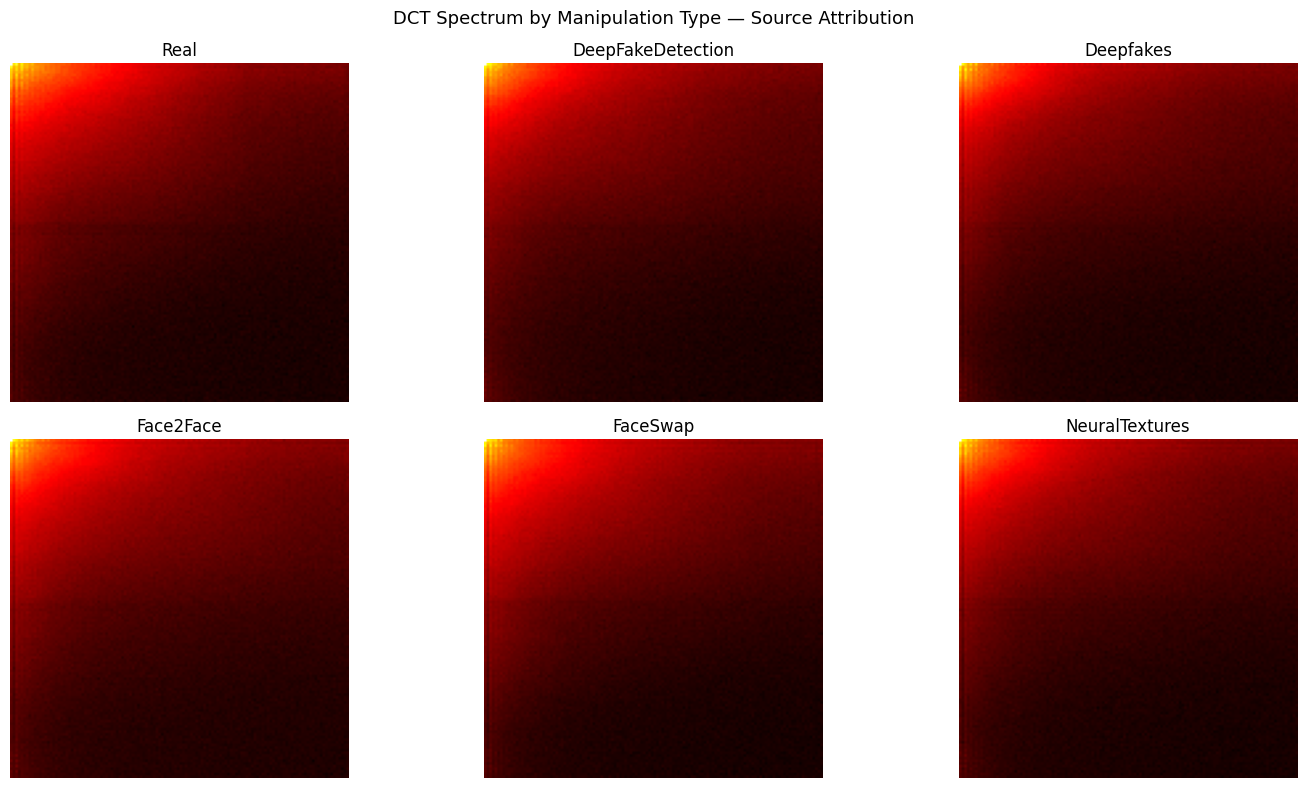

In [6]:
from scipy.fftpack import dct
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def compute_dct_spectrum(img_path):
    img    = Image.open(img_path).convert('L').resize((128, 128))
    img_np = np.array(img, dtype=np.float32)
    dct_2d = dct(dct(img_np, axis=0, norm='ortho'), axis=1, norm='ortho')
    return np.log(np.abs(dct_2d) + 1e-8)

def avg_spectrum(crop_folder, n=200):
    files = os.listdir(crop_folder)[:n]
    specs = [compute_dct_spectrum(os.path.join(crop_folder, f)) for f in files]
    return np.mean(specs, axis=0)

print("Computing spectra...")
spec_real = avg_spectrum(crop_real)
spec_dfd  = avg_spectrum(crop_dfd)
spec_df   = avg_spectrum(crop_df)
spec_f2f  = avg_spectrum(crop_f2f)
spec_fs   = avg_spectrum(crop_fs)
spec_nt   = avg_spectrum(crop_nt)
print("Done")

# Plot all spectra side by side
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
specs = [spec_real, spec_dfd, spec_df, spec_f2f, spec_fs, spec_nt]
names = ['Real', 'DeepFakeDetection', 'Deepfakes', 'Face2Face', 'FaceSwap', 'NeuralTextures']

for ax, spec, name in zip(axes.flat, specs, names):
    ax.imshow(spec, cmap='hot')
    ax.set_title(name)
    ax.axis('off')

plt.suptitle("DCT Spectrum by Manipulation Type — Source Attribution", fontsize=13)
plt.tight_layout()
plt.show()

Radial Profile Comparison

> Plots all 6 frequency profiles on one graph to directly compare them. Each line represents one video type. If the lines are clearly separated and distinguishable from each other, that means each GAN has a unique frequency signature and  source attribution via DCT fingerprinting is feasible. If they all overlap, it's not reliable enough for attribution.



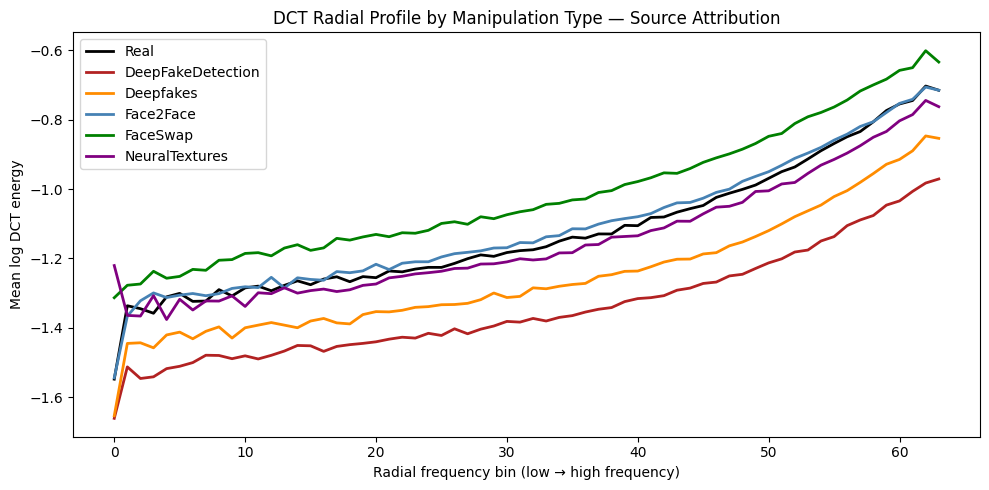

In [7]:
def radial_profile(spectrum):
    h, w  = spectrum.shape
    cy, cx = h // 2, w // 2
    y, x  = np.indices((h, w))
    r     = np.sqrt((x - cx)**2 + (y - cy)**2).astype(int)
    tbin  = np.bincount(r.ravel(), spectrum.ravel())
    count = np.bincount(r.ravel())
    return tbin / (count + 1e-8)

profiles = {
    'Real'              : radial_profile(spec_real),
    'DeepFakeDetection' : radial_profile(spec_dfd),
    'Deepfakes'         : radial_profile(spec_df),
    'Face2Face'         : radial_profile(spec_f2f),
    'FaceSwap'          : radial_profile(spec_fs),
    'NeuralTextures'    : radial_profile(spec_nt),
}

colors = ['black', 'firebrick', 'darkorange', 'steelblue', 'green', 'purple']
max_r  = 64

plt.figure(figsize=(10, 5))
for (name, profile), color in zip(profiles.items(), colors):
    plt.plot(profile[:max_r], label=name, color=color, linewidth=2)

plt.xlabel("Radial frequency bin (low → high frequency)")
plt.ylabel("Mean log DCT energy")
plt.title("DCT Radial Profile by Manipulation Type — Source Attribution")
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
# Show one mouth crop from each type with its Grad-CAM heatmap
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image, preprocess_image

# Load your trained model first
import torch.nn as nn
from torchvision.models import efficientnet_b4, EfficientNet_B4_Weights

weights_pt = EfficientNet_B4_Weights.DEFAULT
model = efficientnet_b4(weights=weights_pt)
model.classifier = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(1792, 2)
)
model.load_state_dict(
    torch.load('/content/drive/MyDrive/deepfake_project/best_model.pth',
               map_location=device)
)
model = model.to(device)
model.eval()
print("✅ Model loaded")

Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth
100%|██████████| 74.5M/74.5M [00:00<00:00, 103MB/s]


✅ Model loaded


Examples

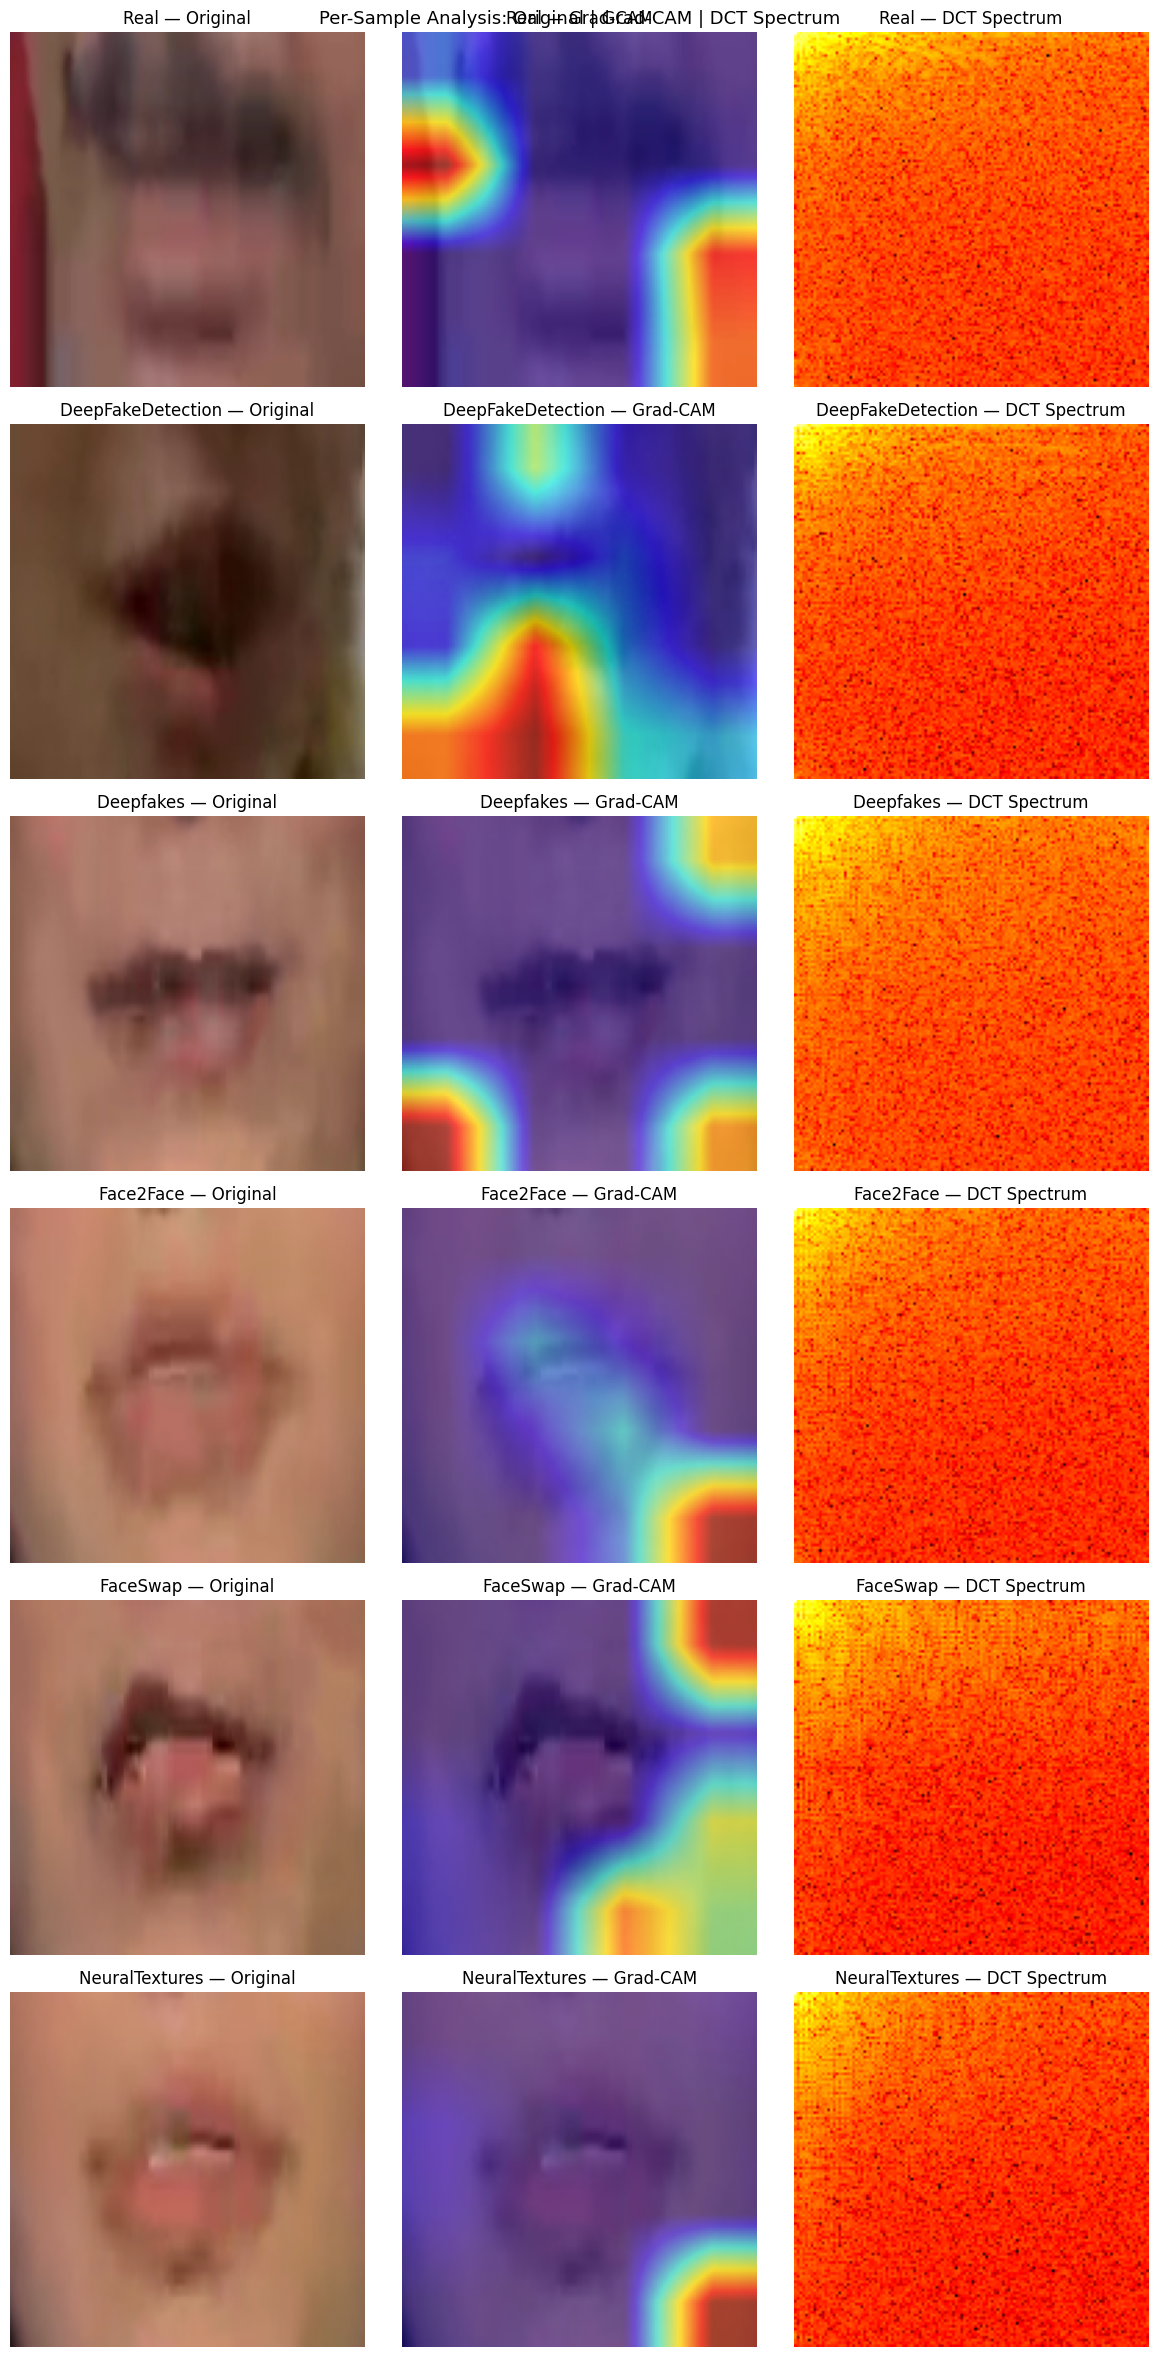

In [9]:
target_layers = [model.features[-1]]

crop_folders = {
    'Real'               : crop_real,
    'DeepFakeDetection'  : crop_dfd,
    'Deepfakes'          : crop_df,
    'Face2Face'          : crop_f2f,
    'FaceSwap'           : crop_fs,
    'NeuralTextures'     : crop_nt,
}

fig, axes = plt.subplots(6, 3, figsize=(12, 24))

for row, (name, folder) in enumerate(crop_folders.items()):
    # Pick one sample
    sample_file = os.listdir(folder)[0]
    sample_path = os.path.join(folder, sample_file)

    img_pil = Image.open(sample_path).convert('RGB').resize((128, 128))
    img_np  = np.array(img_pil) / 255.0

    input_tensor = preprocess_image(
        img_np.astype(np.float32),
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ).to(device)

    with GradCAM(model=model, target_layers=target_layers) as cam:
        grayscale_cam = cam(
            input_tensor=input_tensor,
            targets=[ClassifierOutputTarget(1)]
        )[0]

    visualization = show_cam_on_image(
        img_np.astype(np.float32), grayscale_cam, use_rgb=True
    )

    # Column 1 - original crop
    axes[row][0].imshow(img_np)
    axes[row][0].set_title(f"{name} — Original")
    axes[row][0].axis('off')

    # Column 2 - Grad-CAM
    axes[row][1].imshow(visualization)
    axes[row][1].set_title(f"{name} — Grad-CAM")
    axes[row][1].axis('off')

    # Column 3 - DCT spectrum of this image
    img_gray = np.array(img_pil.convert('L'), dtype=np.float32)
    dct_2d   = dct(dct(img_gray, axis=0, norm='ortho'), axis=1, norm='ortho')
    log_spec = np.log(np.abs(dct_2d) + 1e-8)
    axes[row][2].imshow(log_spec, cmap='hot')
    axes[row][2].set_title(f"{name} — DCT Spectrum")
    axes[row][2].axis('off')

plt.suptitle("Per-Sample Analysis: Original | Grad-CAM | DCT Spectrum", fontsize=13)
plt.tight_layout()
plt.show()

New Training

In [10]:
import os, random
from sklearn.model_selection import train_test_split

crop_real = '/content/drive/MyDrive/deepfake_project/crops/real'
crop_dfd  = '/content/drive/MyDrive/deepfake_project/crops/fake'
crop_df   = '/content/drive/MyDrive/deepfake_project/crops/Deepfakes'
crop_f2f  = '/content/drive/MyDrive/deepfake_project/crops/Face2Face'
crop_fs   = '/content/drive/MyDrive/deepfake_project/crops/FaceSwap'
crop_nt   = '/content/drive/MyDrive/deepfake_project/crops/NeuralTextures'

real_files = [(os.path.join(crop_real, f), 0) for f in os.listdir(crop_real)]

fake_files = (
    [(os.path.join(crop_dfd, f), 1) for f in os.listdir(crop_dfd)] +
    [(os.path.join(crop_df,  f), 1) for f in os.listdir(crop_df)]  +
    [(os.path.join(crop_f2f, f), 1) for f in os.listdir(crop_f2f)] +
    [(os.path.join(crop_fs,  f), 1) for f in os.listdir(crop_fs)]  +
    [(os.path.join(crop_nt,  f), 1) for f in os.listdir(crop_nt)]
)

all_files = real_files + fake_files
random.shuffle(all_files)

paths  = [x[0] for x in all_files]
labels = [x[1] for x in all_files]

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    paths, labels, test_size=0.30, stratify=labels, random_state=42)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.50, stratify=temp_labels, random_state=42)

print(f"Train : {len(train_paths)} images")
print(f"Val   : {len(val_paths)}   images")
print(f"Test  : {len(test_paths)}  images")
print(f"Train real: {train_labels.count(0)} | Train fake: {train_labels.count(1)}")

Train : 8344 images
Val   : 1788   images
Test  : 1788  images
Train real: 1351 | Train fake: 6993


In [11]:
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from PIL import Image

class MouthCropDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths     = paths
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

train_tf = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
val_tf = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = MouthCropDataset(train_paths, train_labels, train_tf)
val_ds   = MouthCropDataset(val_paths,   val_labels,   val_tf)
test_ds  = MouthCropDataset(test_paths,  test_labels,  val_tf)

class_counts = [train_labels.count(0), train_labels.count(1)]
weights  = [1.0 / class_counts[l] for l in train_labels]
sampler  = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=16, sampler=sampler)
val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=16, shuffle=False)
print("✅ DataLoaders ready")

✅ DataLoaders ready


Build Model

In [12]:
import torch.nn as nn
from torchvision.models import efficientnet_b4, EfficientNet_B4_Weights

weights_pt = EfficientNet_B4_Weights.DEFAULT
model = efficientnet_b4(weights=weights_pt)

model.classifier = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(1792, 2)
)

for name, param in model.named_parameters():
    if "features.8" not in name and "classifier" not in name:
        param.requires_grad = False

model = model.to(device)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ Model ready — trainable parameters: {trainable:,}")

✅ Model ready — trainable parameters: 809,986


New Training Loop

In [13]:
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
import torch.nn as nn

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4, weight_decay=1e-4
)
scheduler = CosineAnnealingLR(optimizer, T_max=10)

EPOCHS = 10
best_val_acc = 0.0
history = {"train_loss": [], "val_loss": [], "val_acc": []}

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            out  = model(imgs)
            val_loss += criterion(out, lbls).item()
            preds     = out.argmax(dim=1)
            correct  += (preds == lbls).sum().item()
            total    += lbls.size(0)

    val_acc = correct / total
    scheduler.step()

    history["train_loss"].append(running_loss / len(train_loader))
    history["val_loss"].append(val_loss / len(val_loader))
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(),
                   '/content/drive/MyDrive/deepfake_project/best_model_full.pth')
        print(f"  ✅ New best saved — Val Acc: {val_acc:.4f}")

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"Train Loss: {running_loss/len(train_loader):.4f} | "
          f"Val Loss: {val_loss/len(val_loader):.4f} | "
          f"Val Acc: {val_acc:.4f}")

  ✅ New best saved — Val Acc: 0.6823
Epoch 01/10 | Train Loss: 0.6823 | Val Loss: 0.6389 | Val Acc: 0.6823
Epoch 02/10 | Train Loss: 0.6564 | Val Loss: 0.6396 | Val Acc: 0.6409
Epoch 03/10 | Train Loss: 0.6472 | Val Loss: 0.6793 | Val Acc: 0.5850
Epoch 04/10 | Train Loss: 0.6369 | Val Loss: 0.6466 | Val Acc: 0.6096
Epoch 05/10 | Train Loss: 0.6429 | Val Loss: 0.6239 | Val Acc: 0.6695
Epoch 06/10 | Train Loss: 0.6355 | Val Loss: 0.6397 | Val Acc: 0.6230
Epoch 07/10 | Train Loss: 0.6299 | Val Loss: 0.6368 | Val Acc: 0.6275
Epoch 08/10 | Train Loss: 0.6348 | Val Loss: 0.6278 | Val Acc: 0.6449
Epoch 09/10 | Train Loss: 0.6378 | Val Loss: 0.6383 | Val Acc: 0.6147
Epoch 10/10 | Train Loss: 0.6296 | Val Loss: 0.6215 | Val Acc: 0.6337


NEW RE-TRAINING

In [15]:
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
import torch.nn as nn

# Unfreeze more layers
for name, param in model.named_parameters():
    if "features.6" not in name and "features.7" not in name and "features.8" not in name and "classifier" not in name:
        param.requires_grad = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable:,}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=5e-5, weight_decay=1e-4
)
scheduler = CosineAnnealingLR(optimizer, T_max=15)

EPOCHS = 15
best_val_acc = 0.0
history = {"train_loss": [], "val_loss": [], "val_acc": []}

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            out  = model(imgs)
            val_loss += criterion(out, lbls).item()
            preds     = out.argmax(dim=1)
            correct  += (preds == lbls).sum().item()
            total    += lbls.size(0)

    val_acc = correct / total
    scheduler.step()

    history["train_loss"].append(running_loss / len(train_loader))
    history["val_loss"].append(val_loss / len(val_loader))
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(),
                   '/content/drive/MyDrive/deepfake_project/best_model_full.pth')
        print(f"  ✅ New best saved — Val Acc: {val_acc:.4f}")

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"Train Loss: {running_loss/len(train_loader):.4f} | "
          f"Val Loss: {val_loss/len(val_loader):.4f} | "
          f"Val Acc: {val_acc:.4f}")

  ✅ New best saved — Val Acc: 0.6242
Epoch 01/15 | Train Loss: 0.6352 | Val Loss: 0.6368 | Val Acc: 0.6242
  ✅ New best saved — Val Acc: 0.6270
Epoch 02/15 | Train Loss: 0.6317 | Val Loss: 0.6295 | Val Acc: 0.6270
  ✅ New best saved — Val Acc: 0.6432
Epoch 03/15 | Train Loss: 0.6260 | Val Loss: 0.6180 | Val Acc: 0.6432
Epoch 04/15 | Train Loss: 0.6305 | Val Loss: 0.6416 | Val Acc: 0.6253
  ✅ New best saved — Val Acc: 0.6605
Epoch 05/15 | Train Loss: 0.6259 | Val Loss: 0.6005 | Val Acc: 0.6605
  ✅ New best saved — Val Acc: 0.6700
Epoch 06/15 | Train Loss: 0.6192 | Val Loss: 0.5975 | Val Acc: 0.6700
Epoch 07/15 | Train Loss: 0.6311 | Val Loss: 0.6077 | Val Acc: 0.6639
  ✅ New best saved — Val Acc: 0.6846
Epoch 08/15 | Train Loss: 0.6177 | Val Loss: 0.5806 | Val Acc: 0.6846
  ✅ New best saved — Val Acc: 0.6868
Epoch 09/15 | Train Loss: 0.6261 | Val Loss: 0.6031 | Val Acc: 0.6868
Epoch 10/15 | Train Loss: 0.6234 | Val Loss: 0.6113 | Val Acc: 0.6493
Epoch 11/15 | Train Loss: 0.6189 | Val Lo

Full Model Evaluation

In [17]:
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve

model.load_state_dict(
    torch.load('/content/drive/MyDrive/deepfake_project/best_model_full.pth',
               map_location=device)
)
model.eval()

all_preds, all_probs, all_labels_eval = [], [], []

with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs  = imgs.to(device)
        out   = model(imgs)
        probs = F.softmax(out, dim=1)[:, 1].cpu().numpy()
        preds = out.argmax(dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels_eval.extend(lbls.numpy())

accuracy = accuracy_score(all_labels_eval, all_preds)
f1       = f1_score(all_labels_eval, all_preds)
auc      = roc_auc_score(all_labels_eval, all_probs)

print("=" * 40)
print("  FULL MODEL (all 5 fake types)")
print("=" * 40)
print(f"  Accuracy  : {accuracy:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print(f"  AUC-ROC   : {auc:.4f}")
print("=" * 40)

  FULL MODEL (all 5 fake types)
  Accuracy  : 0.7013
  F1 Score  : 0.8044
  AUC-ROC   : 0.7102


Confusion Matrix and ROC Cureve

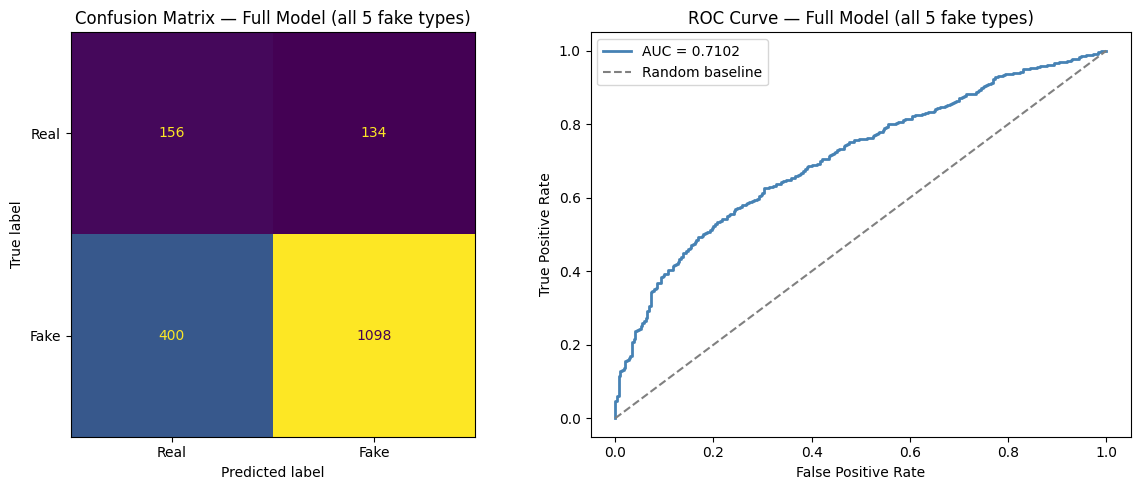

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm   = confusion_matrix(all_labels_eval, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["Real", "Fake"])
disp.plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix — Full Model (all 5 fake types)")

fpr, tpr, _ = roc_curve(all_labels_eval, all_probs)
axes[1].plot(fpr, tpr, label=f"AUC = {auc:.4f}", color="steelblue", linewidth=2)
axes[1].plot([0, 1], [0, 1], '--', color='gray', label="Random baseline")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve — Full Model (all 5 fake types)")
axes[1].legend()

plt.tight_layout()
plt.show()

Load Original Model

In [19]:
model.load_state_dict(
    torch.load('/content/drive/MyDrive/deepfake_project/best_model.pth',
               map_location=device)
)
model.eval()
print("✅ Original model loaded")

✅ Original model loaded
